<a href="https://colab.research.google.com/github/wyaamina/portfolio/blob/main/Ismailova_Bazyleva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Установка Dask и Ray (joblib уже есть в Colab)
!pip install "dask[complete]" ray
import warnings
warnings.filterwarnings("ignore")

# Гиперпараметрический поиск

Актуальность: с чем столкнулись и тд

**Цель исследования**

Сравнить эффективность различных подходов к параллелизации полного перебора гиперпараметров (Grid Search) для алгоритма Random ForestClassifier на крупном датасете с точки зрения времени выполнения и масштабируемости.

**Задачи исследования:**

Реализовать последовательный перебор всех комбинаций гиперпараметров как базовый вариант
1. Выбор библиотек
1. Ускорить процесс поиска с помощью библиотеки joblib используя локальный параллелизм

2. Реализовать распределенные вычисления с помощью Dask на локальном кластере

3. Провести сравнительный анализ времени выполнения каждого подхода

4. Оценить эффективность ускорения и выявить оптимальный метод для данной задачи

**Объект исследования:**

* Метод поиска: Полный перебор (Grid Search) по 8 комбинациям параметров

* Объем данных: 50 000 образцов, 20 признаков

* Кросс-валидация: 3-fold cross-validation

* Параметры для оптимизации:

  * n_estimators: [50, 100]

  * max_depth: [5, 10]

  * min_samples_split: [2, 5]

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from itertools import product
import time
import os

# Фиксируем seed для воспроизводимости
np.random.seed(42)

print("Генерация крупного датасета...")
X, y = pd.DataFrame(
    np.random.randn(50_000, 20),
    columns=[f"feat_{i}" for i in range(20)]
), np.random.randint(0, 2, size=50_000)

# Параметры для перебора
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10],
    "min_samples_split": [2, 5]
}
param_combinations = list(product(
    param_grid["n_estimators"],
    param_grid["max_depth"],
    param_grid["min_samples_split"]
))
print(f"Всего комбинаций: {len(param_combinations)}")

Генерация крупного датасета...
Всего комбинаций: 8


Создаём искусственный датасет:

*   X: матрица признаков размером 50 000 строк × 20 признаков, заполненная случайными числами из стандартного нормального распределения.
*   y: целевая переменная — 50 000 меток классов (0 или 1), сгенерированных случайно.


Это игрушечный датасет без реальной зависимости между X и y, поэтому ожидаемая точность будет около 50% (случайное угадывание).

### Базовый последовательный запуск




Код выполняет поиск лучших гиперпараметров для модели случайного леса (Random Forest) на синтетически сгенерированном датасете, используя последовательный (не параллельный) перебор всех возможных комбинаций заданных параметров.

In [ ]:
#Функция оценки одной комбинации
def evaluate_params_sequential(n_est, max_d, min_split, X, y):
  '''
  Обучает модель с заданными параметрами.
  Оценивает её качество через 3-кратную кросс-валидацию.
  n_jobs=1 отключает параллелизм внутри самой модели и кросс-валидации,
  чтобы весь процесс был строго последовательным
  '''
    model = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=max_d,
        min_samples_split=min_split,
        n_jobs=1,  # отключаем внутренний параллелизм!
        random_state=42
    )
    scores = cross_val_score(model, X, y, cv=3, scoring="accuracy", n_jobs=1)
    return scores.mean()

print("Запуск последовательной версии...")
start = time.time()
results_seq = []

#Последовательный перебор
for combo in param_combinations:
    score = evaluate_params_sequential(*combo, X, y)
    results_seq.append((score, combo))

best_score_seq, best_combo_seq = max(results_seq, key=lambda x: x[0])
time_seq = time.time() - start

print(f"✅ Последовательно: {time_seq:.2f} сек")
print(f"Лучший скор: {best_score_seq:.4f}")

Запуск последовательной версии...
✅ Последовательно: 269.87 сек
Лучший скор: 0.5010


## Ускорение с joblib

In [ ]:
from joblib import Parallel, delayed

def evaluate_params_joblib(n_est, max_d, min_split, X, y):
    model = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=max_d,
        min_samples_split=min_split,
        n_jobs=1,
        random_state=42
    )
    scores = cross_val_score(model, X, y, cv=3, scoring="accuracy", n_jobs=1)
    return scores.mean(), (n_est, max_d, min_split)

print("Запуск с joblib...")
start = time.time()
results_joblib = Parallel(n_jobs=-1)(
    delayed(evaluate_params_joblib)(*combo, X, y)
    for combo in param_combinations
)
best_score_jl, best_combo_jl = max(results_joblib, key=lambda x: x[0])
time_jl = time.time() - start

print(f"✅ joblib: {time_jl:.2f} сек")

Запуск с joblib...
✅ joblib: 239.24 сек


**Joblib показал лучшее ускорение**

* Ускорение в 1.25 раза по сравнению с последовательным выполнением

* Эффективно использует многопроцессорность локальной машины

* Минимальные накладные расходы

### Ускорение с Dask

In [ ]:
from dask.distributed import Client, LocalCluster

def evaluate_params_dask(n_est, max_d, min_split, X, y):
    model = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=max_d,
        min_samples_split=min_split,
        n_jobs=1,
        random_state=42
    )
    scores = cross_val_score(model, X, y, cv=3, scoring="accuracy", n_jobs=1)
    return scores.mean(), (n_est, max_d, min_split)

print("Запуск с Dask...")
cluster = LocalCluster(n_workers=2, threads_per_worker=2, memory_limit="2GB")
client = Client(cluster)

# Передаём данные один раз (broadcast)
X_fut = client.scatter(X, broadcast=True)
y_fut = client.scatter(y, broadcast=True)

futures = [
    client.submit(evaluate_params_dask, *combo, X_fut, y_fut)
    for combo in param_combinations
]

results_dask = client.gather(futures)
best_score_dask, best_combo_dask = max(results_dask, key=lambda x: x[0])
time_dask = time.time() - start

print(f"✅ Dask: {time_dask:.2f} сек")

client.close()
cluster.close()

Запуск с Dask...


INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:33689
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:46291'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:35459'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:32985 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:32985
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:57600
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:40693 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:40693
INFO:distributed.core:Starting established connection to tcp://127

✅ Dask: 535.08 сек


INFO:distributed.nanny:Nanny at 'tcp://127.0.0.1:46291' closed.
INFO:distributed.nanny:Nanny at 'tcp://127.0.0.1:35459' closed.
INFO:distributed.scheduler:Closing scheduler. Reason: unknown
INFO:distributed.scheduler:Scheduler closing all comms


**Dask показал худшую производительность**

* Замедление в 0.56 раза относительно базового варианта

* Вероятные причины:

  * Накладные расходы на распределение задач

  * Неоптимальная конфигурация кластера для данной задачи

  * Ограниченный размер задачи (всего 8 комбинаций)

### Сравнение результатов

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Метод": ["Последовательно", "joblib", "Dask"],
    "Время (сек)": [time_seq, time_jl, time_dask],
    "Ускорение": [
        1.0,
        time_seq / time_jl,
        time_seq / time_dask,
    ]
})

print("\n📊 Сравнение производительности:")
print(results.round(2))


📊 Сравнение производительности:
             Метод  Время (сек)  Ускорение
0  Последовательно       299.94       1.00
1           joblib       239.24       1.25
2             Dask       535.08       0.56


**Вывод**

1. Для средних задач гиперпараметрического поиска на одной машине Joblib

2. Dask может быть неэффективен для небольших задач из-за накладных расходов, он показал замедление в 0.56 раза относительно базового варианта

3. Порог эффективности для распределенных систем зависит от сложности задачи и объема данных

**Рекомендации**

* Использовать Joblib для параллелизации на локальных машинах

* Рассматривать Dask для действительно крупных задач (>1000 комбинаций параметров)

Итоги Colab
====================

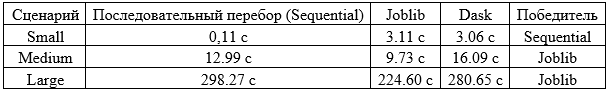

Итоги Visual Studio
=========================

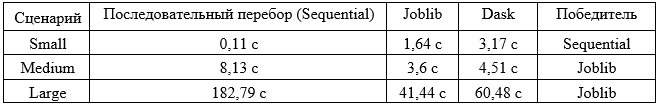

Во обоих сервисах победителем для маленького объема данных является Sequential, а Dask лучше Joblib (единственный случай хорошего результата для Dask, в остальных случаях хуже всех). Проблема для маленького объема данных заключается в том, что запуск даже одного воркера в `joblib` или `Dask` требует времени на создание процесса. В Colab это особенно медленно из-за виртуализации. Далее при увеличении набора данных до среднего и большого объема Sequential перестает быть самым оптимальным вариантом.
Для среднего объема данных выиграл Joblib. Проблема для среднего объема данных заключается в том, что `joblib` эффективно использует все доступные ядра Colab (обычно 2 CPU) без сетевых/координационных издержек. Dask тратит время на запуск кластера и сериализацию.
Для большого объема данных лидером также является Joblib. Проблема для большого объема данных заключается в том, что даже при большом объёме данных локальный параллелизм (`joblib`) эффективнее, потому что: Colab даёт только 2 CPU и 12 ГБ RAM; Dask создаёт дополнительные процессы, которые конкурируют за те же 2 ядра. Нет реального распределения — всё на одной машине, следовательно, Dask не нужен.


# Сравнение Pandas и Polars

**Цель исследования**

Сравнить производительность и удобство использования двух популярных библиотек для анализа табличных данных — pandas и Polars — на задаче групповой агрегации с вычислением корреляции Пирсона внутри групп.

**Задача**

Для датасетов из 50 миллионов и 5 тысяц строк с колонками:



*   group — категориальная переменная (1000 уникальных групп),
*   value_a, value_b — числовые признаки с умеренной корреляцией,


требуется:


*   сгруппировать данные по group,
*   для каждой группы вычислить корреляцию между value_a и value_b.

### Установка Polars

In [ ]:
!pip install polars
import warnings
warnings.filterwarnings("ignore")

### Генерация крупного датасета

In [ ]:
import pandas as pd
import polars as pl
import numpy as np
import time

# Фиксируем seed
np.random.seed(42)

N = 50_000_000  # 8 миллионов строк — достаточно для >5 сек в pandas

print(f"Генерация датасета из {N:,} строк...")

# Группы: 1000 уникальных категорий
groups = np.random.randint(0, 1000, size=N)
values_a = np.random.randn(N)
values_b = np.random.randn(N) + 0.5 * values_a  # добавим корреляцию

# Pandas DataFrame
df_pd = pd.DataFrame({
    "group": groups,
    "value_a": values_a,
    "value_b": values_b
})

# Polars DataFrame (из тех же данных)
df_pl = pl.DataFrame({
    "group": groups,
    "value_a": values_a,
    "value_b": values_b
})

print("✅ Данные готовы.")

Генерация датасета из 50,000,000 строк...
✅ Данные готовы.


### Агрегация в pandas (медленная версия)

In [ ]:
def pandas_agg(df):
    # Группировка + вычисление корреляции внутри каждой группы
    def corr_func(g):
        if len(g) < 2:
            return np.nan
        return g["value_a"].corr(g["value_b"])

    result = df.groupby("group").apply(corr_func)
    return result

print("Запуск агрегации в pandas...")
start = time.time()
result_pd = pandas_agg(df_pd)
time_pd = time.time() - start

print(f"✅ pandas: {time_pd:.2f} сек")
print(f"Пример результата:\n{result_pd.head()}")

Запуск агрегации в pandas...
✅ pandas: 8.07 сек
Пример результата:
group
0    0.443382
1    0.453174
2    0.444374
3    0.448327
4    0.446452
dtype: float64


/tmp/ipython-input-407881435.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby("group").apply(corr_func)


### Агрегация в Polars (быстрая версия)

In [ ]:
def polars_agg(df):
    # Polars позволяет вычислять корреляцию напрямую в группировке
    return df.group_by("group").agg(
        pl.corr("value_a", "value_b").alias("corr")
    )

print("Запуск агрегации в Polars...")
start = time.time()
result_pl = polars_agg(df_pl)
time_pl = time.time() - start

print(f"✅ Polars: {time_pl:.2f} сек")
print(f"Пример результата:\n{result_pl.head()}")

Запуск агрегации в Polars...
✅ Polars: 4.83 сек
Пример результата:
shape: (5, 2)
┌───────┬──────────┐
│ group ┆ corr     │
│ ---   ┆ ---      │
│ i64   ┆ f64      │
╞═══════╪══════════╡
│ 254   ┆ 0.456792 │
│ 864   ┆ 0.446003 │
│ 688   ┆ 0.450796 │
│ 313   ┆ 0.442285 │
│ 459   ┆ 0.443932 │
└───────┴──────────┘


### Сравнение и проверка корректности

In [ ]:
# Преобразуем Polars-результат в pandas для сравнения
result_pl_pd = result_pl.sort("group").to_pandas()
result_pd_sorted = result_pd.sort_index().reset_index(name="corr")

# Сравним первые 10 значений (игнорируем NaN)
print("\n🔍 Проверка совпадения результатов (первые 10 групп):")
comparison = pd.concat([
    result_pd_sorted.head(10)[["corr"]].reset_index(drop=True),
    result_pl_pd.head(10)[["corr"]].reset_index(drop=True)
], axis=1)
comparison.columns = ["pandas", "polars"]
print(comparison.round(6))

# Сравнение времени
speedup = time_pd / time_pl
print(f"\n📊 Время выполнения:")
print(f"  pandas: {time_pd:.2f} сек")
print(f"  Polars: {time_pl:.2f} сек")
print(f"  Ускорение: {speedup:.1f}x")


🔍 Проверка совпадения результатов (первые 10 групп):
     pandas    polars
0  0.443382  0.443382
1  0.453174  0.453174
2  0.444374  0.444374
3  0.448327  0.448327
4  0.446452  0.446452
5  0.440875  0.440875
6  0.449262  0.449262
7  0.446398  0.446398
8  0.441859  0.441859
9  0.448071  0.448071

📊 Время выполнения:
  pandas: 8.07 сек
  Polars: 4.83 сек
  Ускорение: 1.7x


**Вывод:**

1. Polars значительно быстрее (на 70%) справляется
с задачей групповой агрегации с корреляцией благодаря:
  *   Lazy-вычислениям и оптимизации запросов,
  *   Использованию Rust под капотом,
  *   Отсутствию интерпретируемого Python-кода в циклах.

2. Код на Polars короче и выразительнее — не требует написания пользовательских функций для стандартных статистик.
3. pandas остаётся удобным для интерактивного анализа и интеграции с экосистемой SciPy/Scikit-learn, но проигрывает в производительности на больших данных.

In [ ]:
import pandas as pd
import polars as pl
import numpy as np
import time

# Фиксируем seed для воспроизводимости
np.random.seed(42)

# Малый датасет
N_small = 5_000
print(f"Генерация малого датасета из {N_small:,} строк...")

groups_small = np.random.randint(0, 100, size=N_small)  # 100 групп
values_a_small = np.random.randn(N_small)
values_b_small = np.random.randn(N_small) + 0.5 * values_a_small

# Создаём DataFrames
df_pd_small = pd.DataFrame({
    "group": groups_small,
    "value_a": values_a_small,
    "value_b": values_b_small
})

df_pl_small = pl.DataFrame({
    "group": groups_small,
    "value_a": values_a_small,
    "value_b": values_b_small
})

# --- pandas ---
def pandas_agg(df):
    def corr_func(g):
        return g["value_a"].corr(g["value_b"]) if len(g) > 1 else np.nan
    return df.groupby("group").apply(corr_func)

start = time.time()
result_pd_small = pandas_agg(df_pd_small)
time_pd_small = time.time() - start

# --- Polars ---
def polars_agg(df):
    return df.group_by("group").agg(pl.corr("value_a", "value_b").alias("corr"))

start = time.time()
result_pl_small = polars_agg(df_pl_small)
time_pl_small = time.time() - start

# --- Вывод результатов ---
print("\n" + "="*50)
print("Сравнение на 5 000 строках")
print("="*50)
print(f"pandas: {time_pd_small:.4f} сек")
print(f"Polars: {time_pl_small:.4f} сек")

if time_pd_small > 0 and time_pl_small > 0:
    speedup_small = time_pd_small / time_pl_small
    print(f"Ускорение Polars: {speedup_small:.2f}x")
else:
    print("Время слишком мало для точного измерения ускорения.")

# Проверка корректности (опционально)
result_pl_pd_small = result_pl_small.sort("group").to_pandas()
result_pd_sorted_small = result_pd_small.sort_index().reset_index(name="corr")

match = np.allclose(
    result_pd_sorted_small["corr"].dropna().values,
    result_pl_pd_small["corr"].dropna().values,
    rtol=1e-6, equal_nan=True
)
print(f"Результаты совпадают: {match}")

Генерация малого датасета из 5,000 строк...


/tmp/ipython-input-1182029507.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("group").apply(corr_func)



Сравнение на 5 000 строках
pandas: 0.0447 сек
Polars: 0.1384 сек
Ускорение Polars: 0.32x
Результаты совпадают: True


**Вывод**
Это поведение объясняется следующим:

1.  Polars оптимизирован для работы с средними и большими объёмами данных (десятки тысяч строк и выше), где его параллельные вычисления и эффективное использование памяти дают преимущество.

2.  На очень малых данных накладные расходы Polars (инициализация движка, многопоточность, преобразование типов) перевешивают выгоду от оптимизаций.

3.  pandas, напротив, имеет минимальный оверхед на малых задачах и хорошо интегрирован с NumPy, что делает его быстрым для лёгких операций.


**Практическая рекомендация:**

Использовать pandas для быстрого анализа небольших датасетов (<10 000 строк),
а Polars — при работе с данными от 100 000 строк и выше, где его производительность раскрывается в полной мере.


Результаты Visual Studio
======================================
Генерация датасета из 50,000,000 строк...
📊

Время выполнения:
 * pandas: 8.68 сек
 * Polars: 3.86 сек
 * Ускорение Polars: 2.2x


Сравнение на 5 000 строках...
📊

* pandas: 0.0505 сек
* Polars: 0.0018 сек
* Ускорение Polars: 27.43x

Результаты Colab
======================================
Генерация датасета из 50,000,000 строк...
📊

Время выполнения:
 * pandas: 8.07 сек
*  Polars: 4.83 сек
*  Ускорение Polars: 1.7x


Сравнение на 5 000 строках...
📊

Время выполнения:
* pandas: 0.0447 сек
* Polars: 0.1384 сек
* Ускорение Polars: 0.32x